<a target="_blank" href="https://colab.research.google.com/github/gbonilla712/boston-housing-price-prediction/blob/main/GBonilla_Boston_House_Price_Prediction_Solution_Notebook.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **Regression Project: Boston House Price Prediction**

# **Marks: 60**

Welcome to the project on regression. We will use the **Boston house price dataset** for this project.

-------------------------------
## **Objective**
-------------------------------

The problem at hand is to **predict the housing prices of a town or a suburb based on the features of the locality provided to us**. In the process, we need to **identify the most important features affecting the price of the house**. We need to employ techniques of data preprocessing and build a linear regression model that predicts the prices for the unseen data.

----------------------------
## **Dataset**
---------------------------

Each record in the database describes a suburb or town in a Boston. The data was drawn from the Boston Standard Metropolitan Statistical Area (SMSA) in 1970. Detailed attribute information can be found below:

Attribute Information:

- **CRIM:** Per capita crime rate by town
- **ZN:** Proportion of residential land zoned for lots over 25,000 sq.ft.
- **INDUS:** Proportion of non-retail business acres per town
- **CHAS:** Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- **NOX:** Nitric Oxide concentration (parts per 10 million)
- **RM:** The average number of rooms per dwelling
- **AGE:** Proportion of owner-occupied units built before 1940
- **DIS:** Weighted distances to five Boston employment centers
- **RAD:** Index of accessibility to radial highways
- **TAX:** Full-value property-tax rate per 10,000 dollars
- **PTRATIO:** Pupil-teacher ratio by town
- **LSTAT:** % lower status of the population
- **MEDV:** Median value of owner-occupied homes in 1000 dollars

### **Please read the instructions carefully before starting the project.**

This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned. Read along carefully to complete the project.

* Blanks '_______' are provided in the notebook that needs to be filled with an appropriate code to get the correct result. Please replace the blank with the right code snippet. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# Fill in the blank" or "# Complete the code". Running incomplete code may throw an error.
* Remove the blank and state your observations in detail wherever the mark down says 'Write your observations here:_________'
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* You can the results/observations derived from the analysis here and use them to create your final report.

## **Importing the necessary libraries and overview of the dataset**

In [ ]:
# Import libraries for data manipulation
import pandas as pd

import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt

import seaborn as sns

from statsmodels.graphics.gofplots import ProbPlot

# Import libraries for building linear regression model
from statsmodels.formula.api import ols

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression

# Import library for preparing data
from sklearn.model_selection import train_test_split

# Import library for data preprocessing
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Loading the data**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning Elective Project/Boston.csv") ## Complete the code

In [ ]:
data = df.copy()

In [ ]:
# Return the first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


**Write your observations here:___________**

### **Data Overview**

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [ ]:
# Return the last 5 rows
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,7.88,11.9


In [ ]:
# Check the shape of the dataset
df.shape

(506, 13)

In [ ]:
# Check the data types of the different columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


**Observations:**

- There are a total of **506 non-null observations in each of the columns**. This indicates that there are **no missing values** in the data.
- There are **13 columns** in the dataset and **every column is of numeric data type**.

In [ ]:
# Check for duplicate entries in the dataset
df.duplicated().sum()

np.int64(0)

### **Summary Statistics of this Dataset**

In [ ]:
# Get the summary statistics of the all numerical and categorical variables
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.61,8.60,0.01,0.08,0.26,3.68,88.98
ZN,506.0,11.36,23.32,0.00,0.00,0.00,12.50,100.00
INDUS,506.0,11.14,6.86,0.46,5.19,9.69,18.10,27.74
CHAS,506.0,0.07,0.25,0.00,0.00,0.00,0.00,1.00
NOX,506.0,0.55,0.12,0.38,0.45,0.54,0.62,0.87
RM,506.0,6.28,0.70,3.56,5.89,6.21,6.62,8.78
AGE,506.0,68.57,28.15,2.90,45.02,77.50,94.07,100.00
DIS,506.0,3.80,2.11,1.13,2.10,3.21,5.19,12.13
RAD,506.0,9.55,8.71,1.00,4.00,5.00,24.00,24.00
TAX,506.0,408.24,168.54,187.00,279.00,330.00,666.00,711.00


In [ ]:
# Get the summary statistics of the numerical non-categorical variables
df.drop(columns=['CHAS', 'RAD']).describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.61,8.60,0.01,0.08,0.26,3.68,88.98
ZN,506.0,11.36,23.32,0.00,0.00,0.00,12.50,100.00
INDUS,506.0,11.14,6.86,0.46,5.19,9.69,18.10,27.74
NOX,506.0,0.55,0.12,0.38,0.45,0.54,0.62,0.87
RM,506.0,6.28,0.70,3.56,5.89,6.21,6.62,8.78
AGE,506.0,68.57,28.15,2.90,45.02,77.50,94.07,100.00
DIS,506.0,3.80,2.11,1.13,2.10,3.21,5.19,12.13
TAX,506.0,408.24,168.54,187.00,279.00,330.00,666.00,711.00
PTRATIO,506.0,18.46,2.16,12.60,17.40,19.05,20.20,22.00
LSTAT,506.0,12.65,7.14,1.73,6.95,11.36,16.96,37.97


**Write your observations here:___________**

### Checking for missing values

In [ ]:
# Check for missing values for each column in the dataset
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


## **Exploratory Data Analysis and Data Preprocessing**

### **Univariate Analysis**

**Let's check the distribution of the variables**

In [ ]:
# Function to create labeled barplots for categorical non-numerical variables

def labeled_barplot(data, feature, perc = False, n = None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])            # Length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize = (count + 1, 5))
    else:
        plt.figure(figsize = (n + 1, 5))

    plt.xticks(rotation = 90, fontsize = 15)
    ax = sns.countplot(
        data = data,
        x = feature,
        palette = "Paired",
        order = data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )                              # Percentage of each class of the category
        else:
            label = p.get_height()         # Count of each level of the category

        x = p.get_x() + p.get_width() / 2  # Width of the plot
        y = p.get_height()                 # Height of the plot

        ax.annotate(
            label,
            (x, y),
            ha = "center",
            va = "center",
            size = 12,
            xytext = (0, 5),
            textcoords = "offset points",
        )                                 # Annotate the percentage

    plt.show()                            # Show the plot

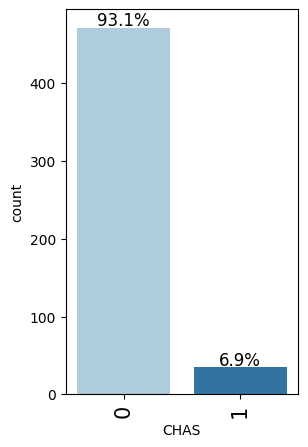

In [ ]:
labeled_barplot(df, "CHAS", perc = True)

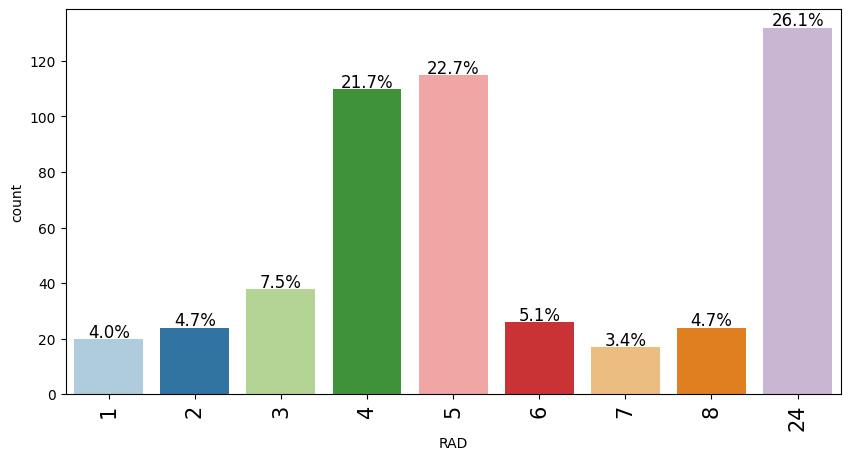

In [ ]:
labeled_barplot(df, "RAD", perc = True)

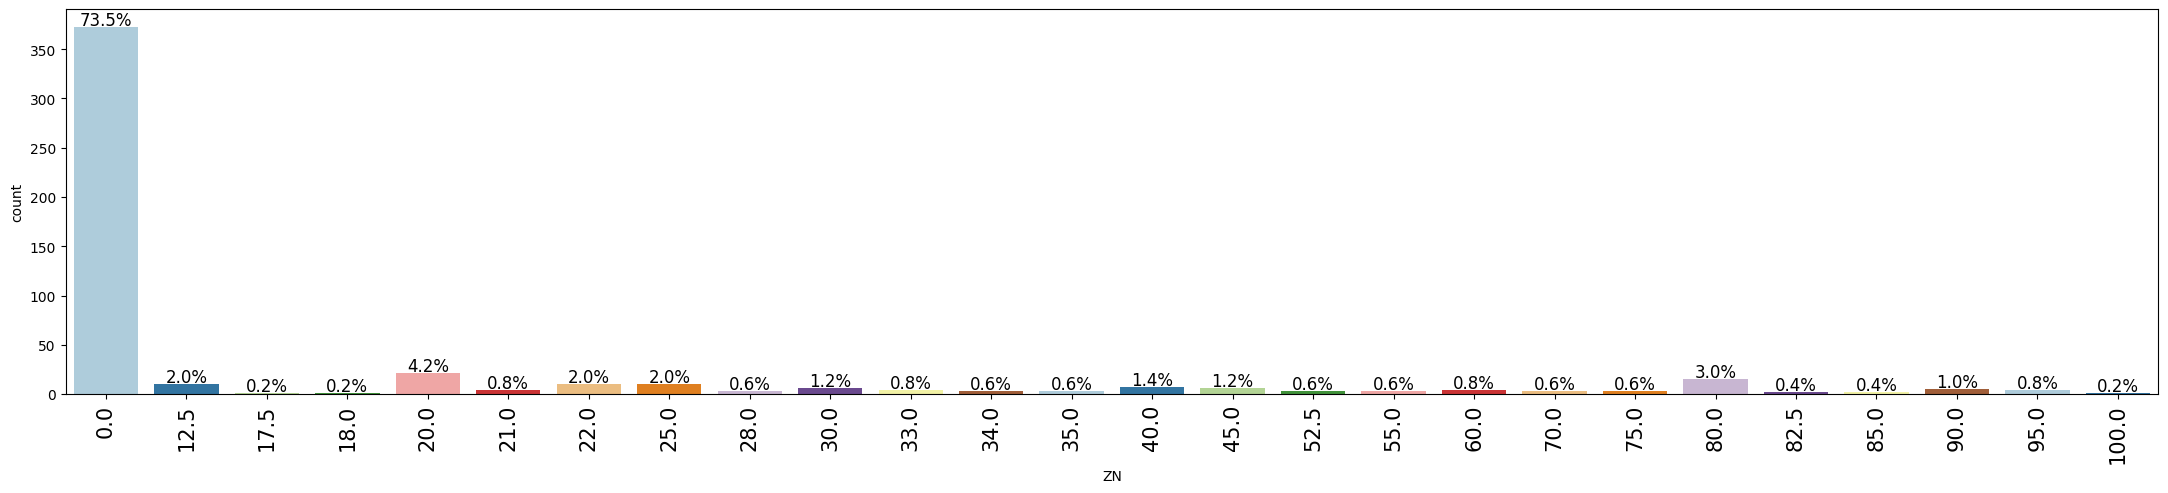

In [ ]:
labeled_barplot(df, "ZN", perc = True)

In [ ]:
# Function to plot a boxplot and a histogram along the same scale for numerical variables

def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,      # Number of rows of the subplot grid = 2
        sharex = False,  # x-axis will not be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )                   # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "violet"
    )                   # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = True, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = True, ax = ax_hist2
    )                   # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )                   # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )                   # Add median to the histogram

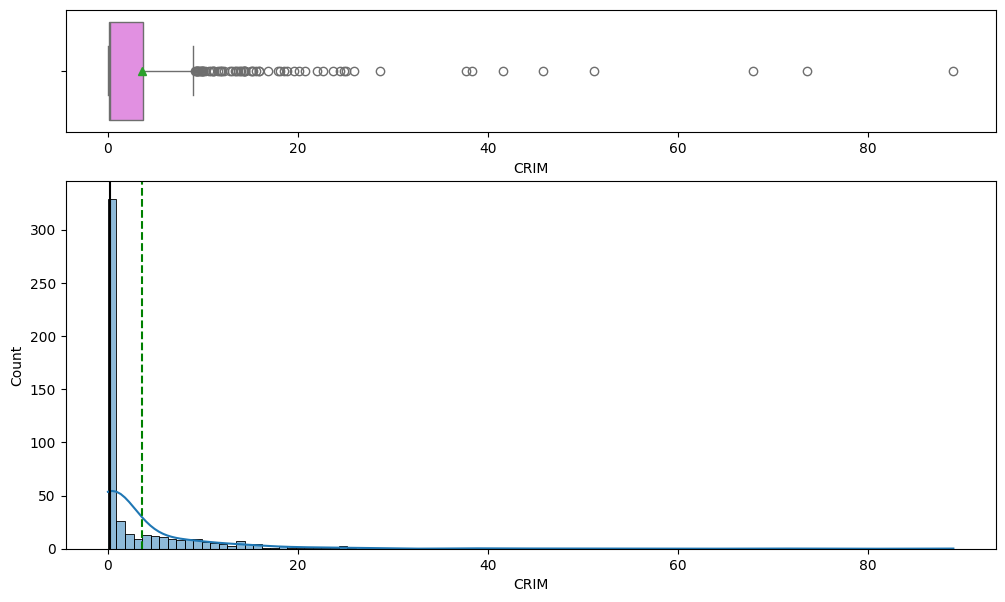

In [ ]:
histogram_boxplot(df, "CRIM")

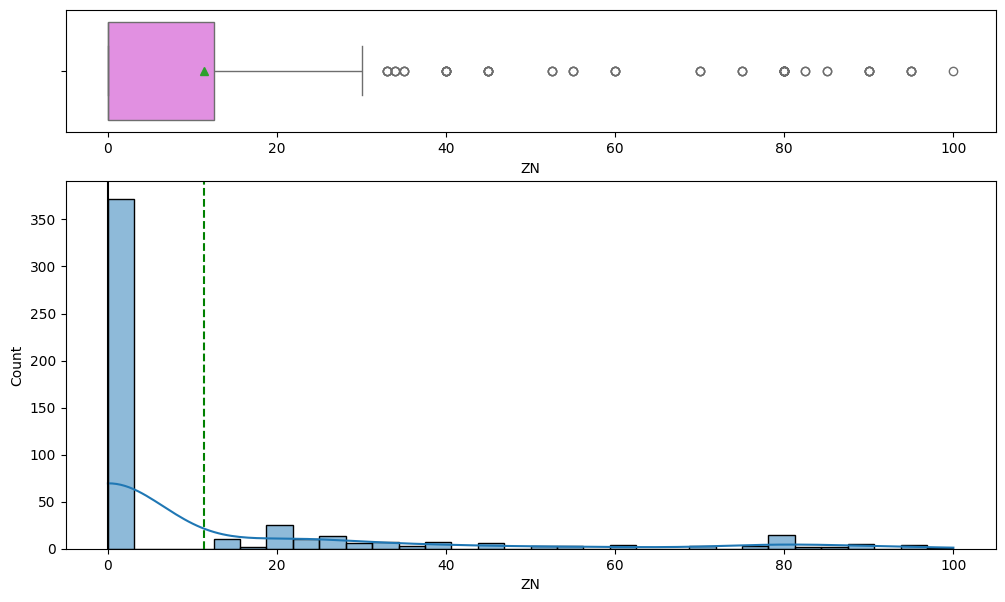

In [ ]:
histogram_boxplot(df, "ZN")

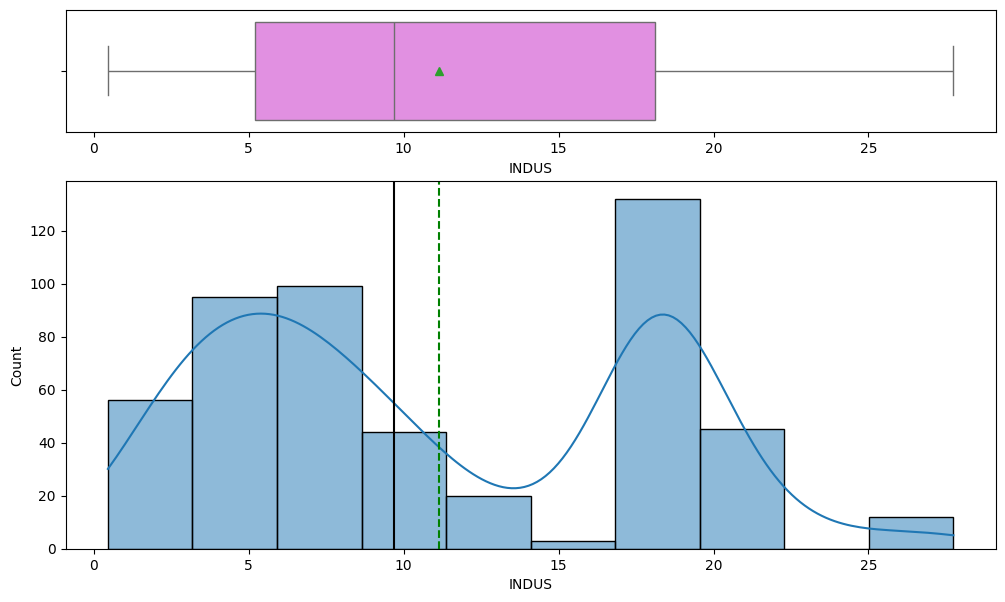

In [ ]:
histogram_boxplot(df, "INDUS")

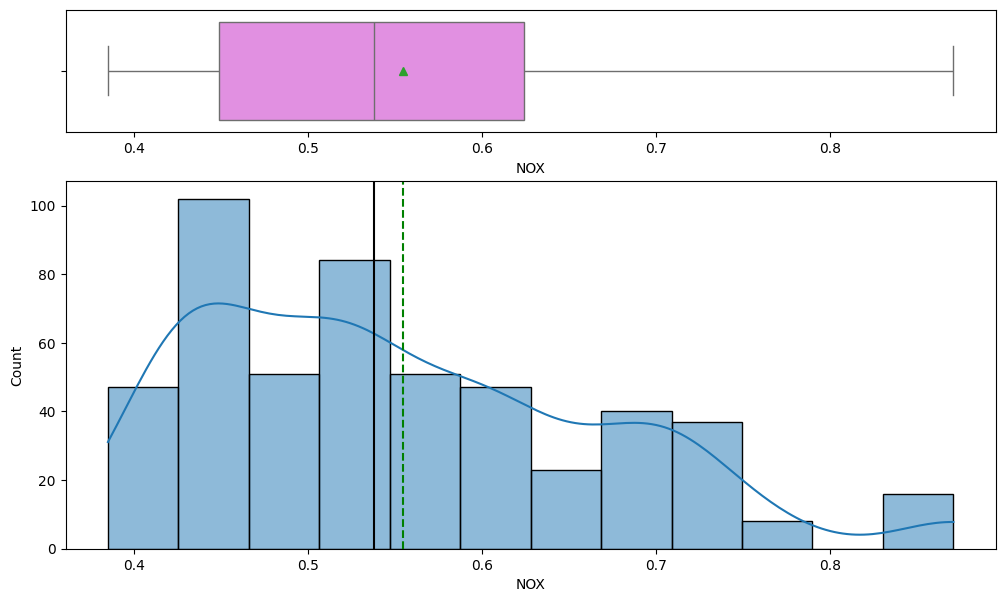

In [ ]:
histogram_boxplot(df, "NOX")

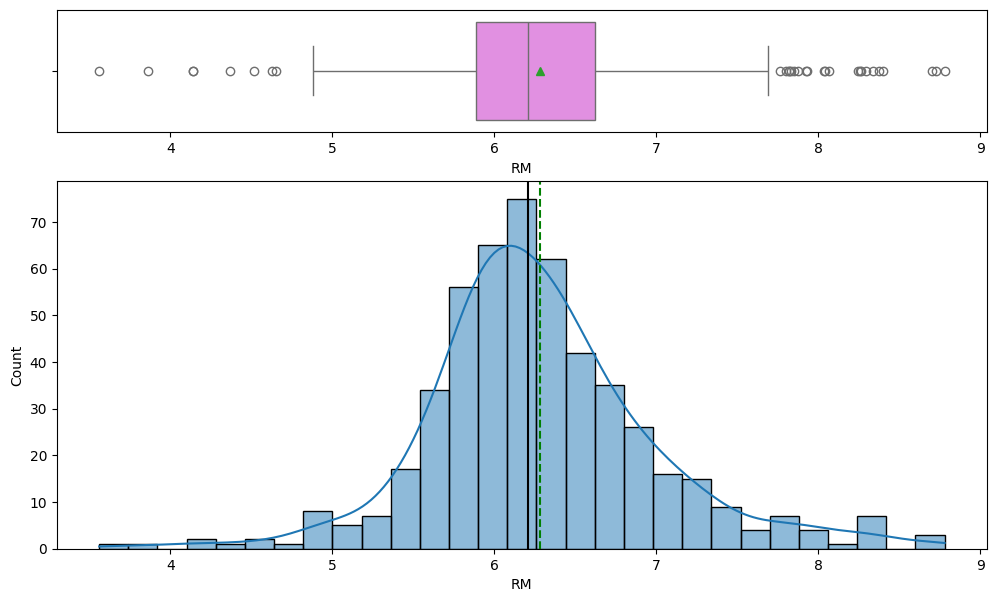

In [ ]:
histogram_boxplot(df, "RM")

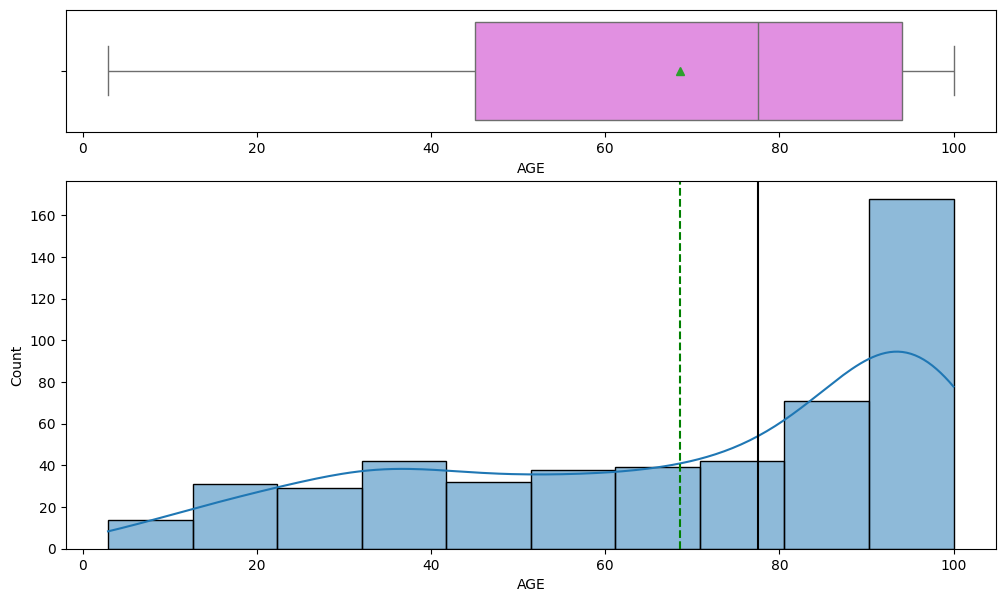

In [ ]:
histogram_boxplot(df, "AGE")

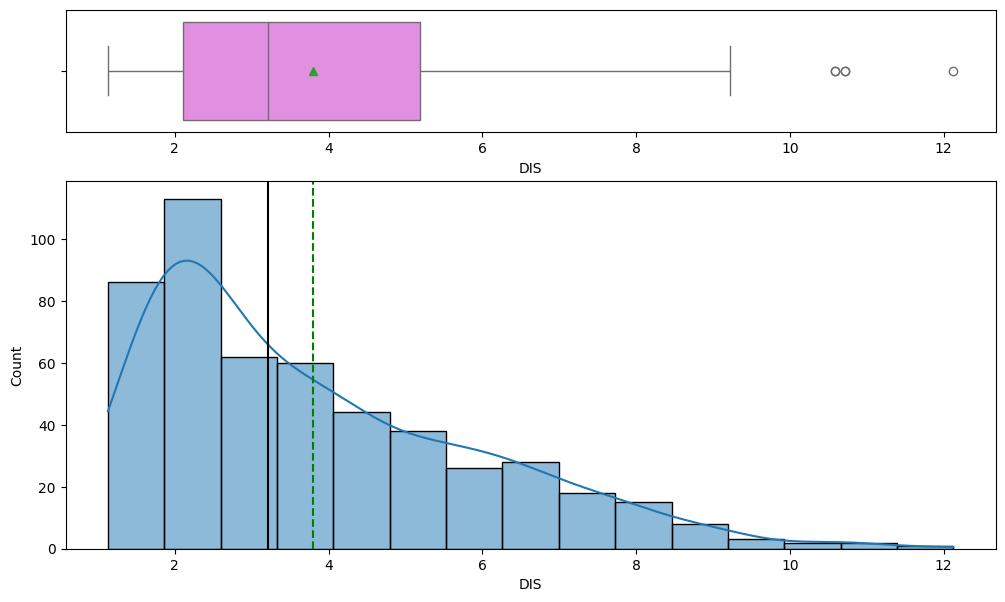

In [ ]:
histogram_boxplot(df, "DIS")

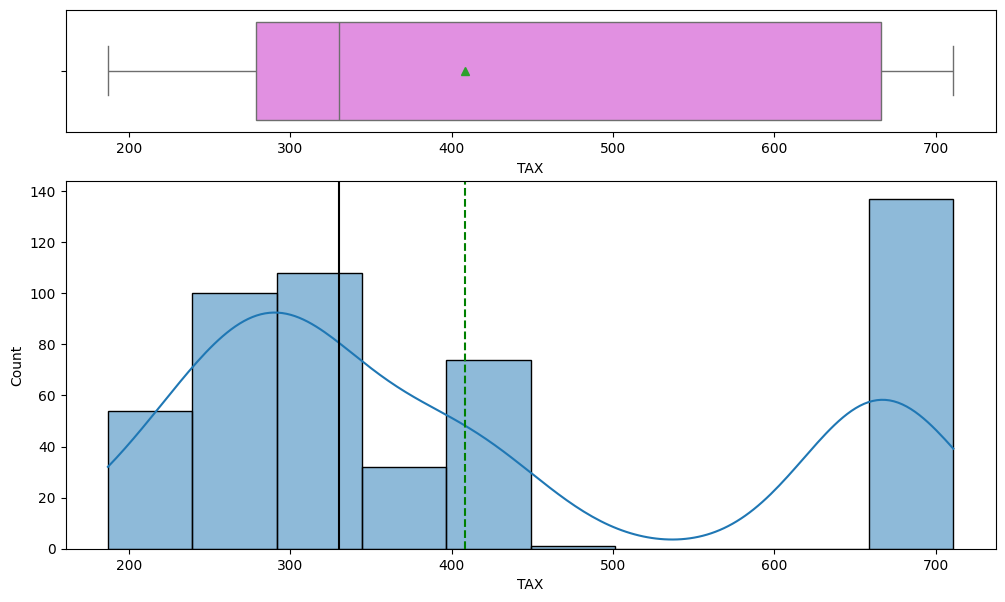

In [ ]:
histogram_boxplot(df, "TAX")

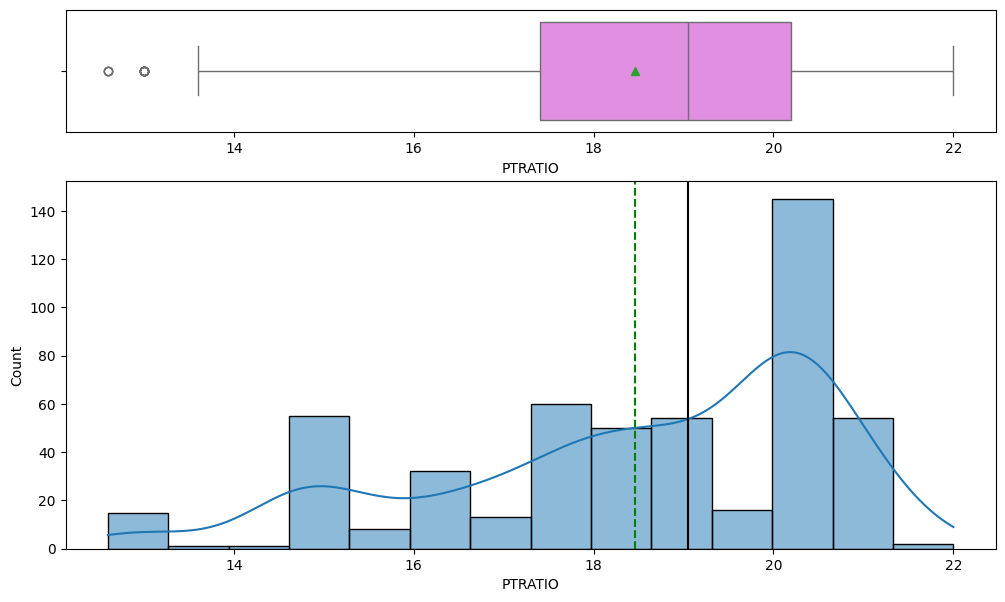

In [ ]:
histogram_boxplot(df, "PTRATIO")

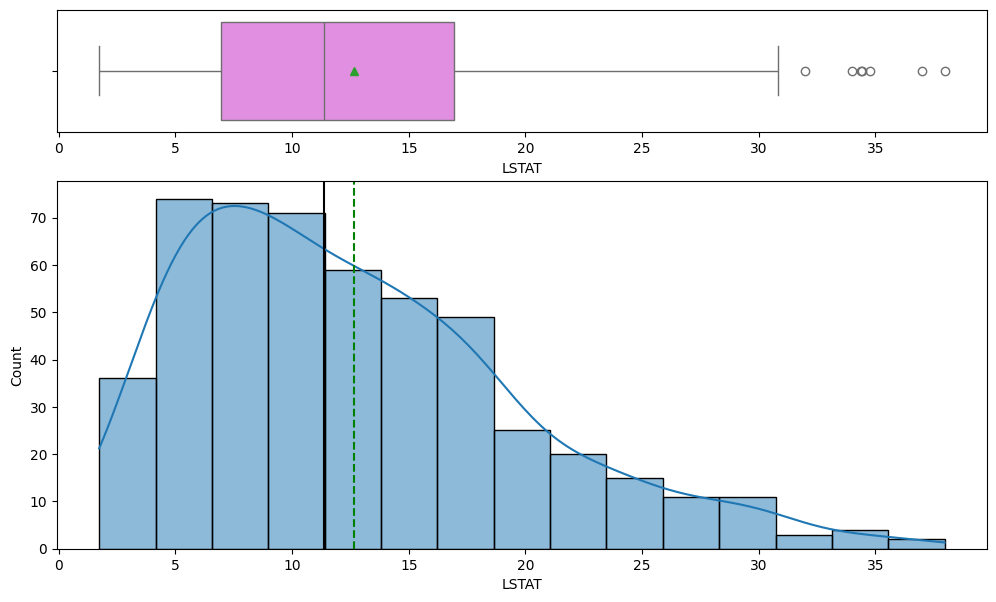

In [ ]:
histogram_boxplot(df, "LSTAT")

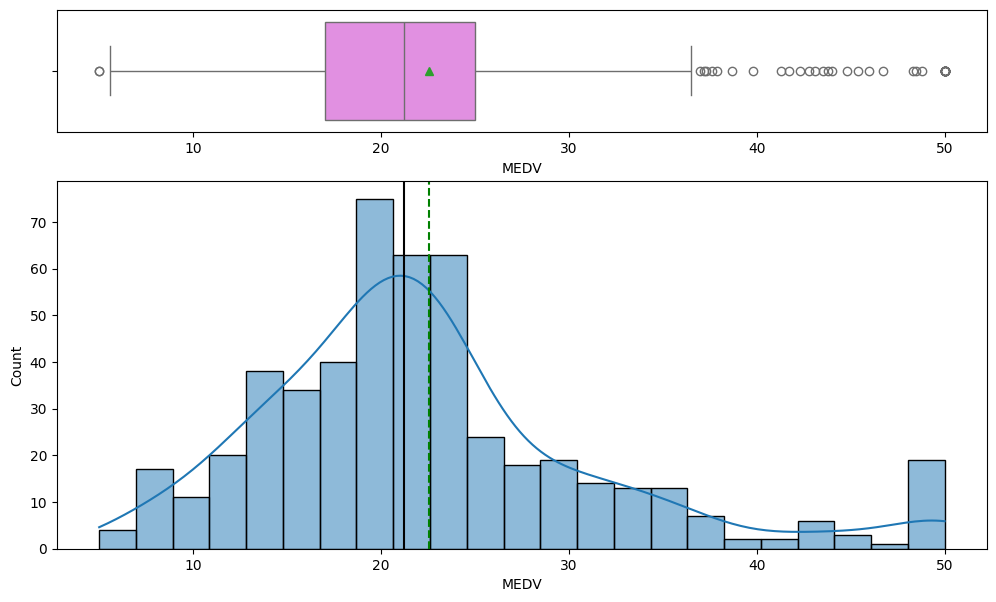

In [ ]:
histogram_boxplot(df, "MEDV")

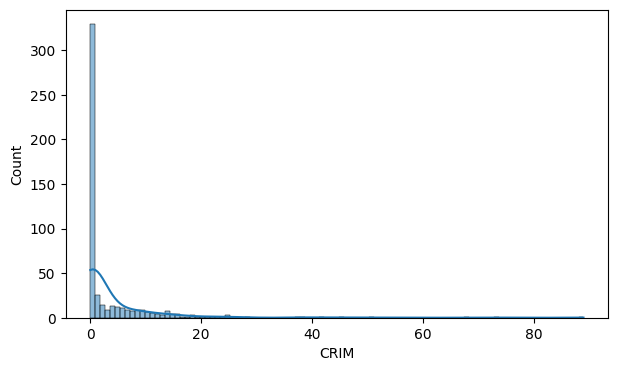

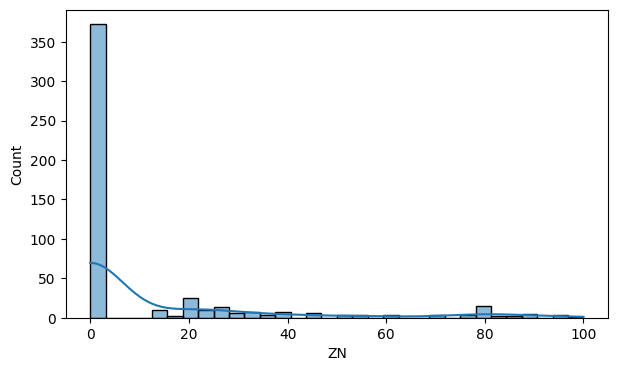

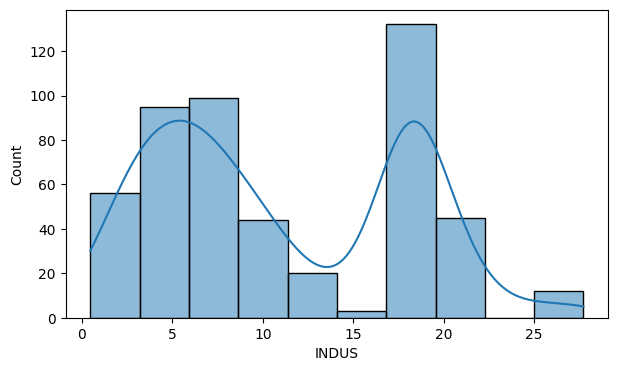

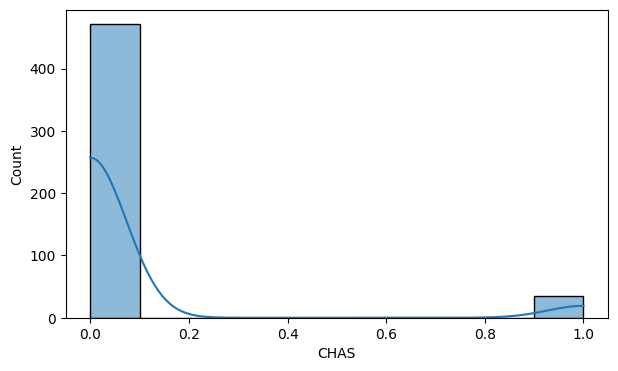

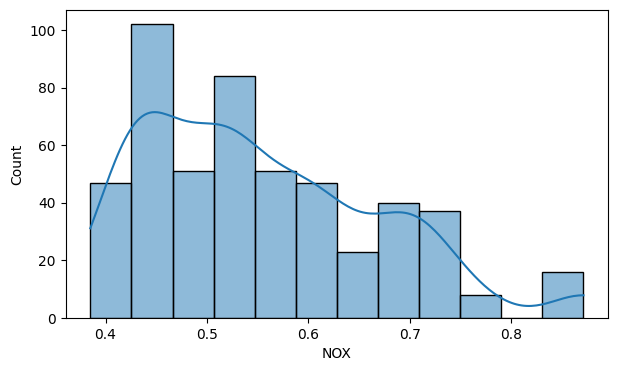

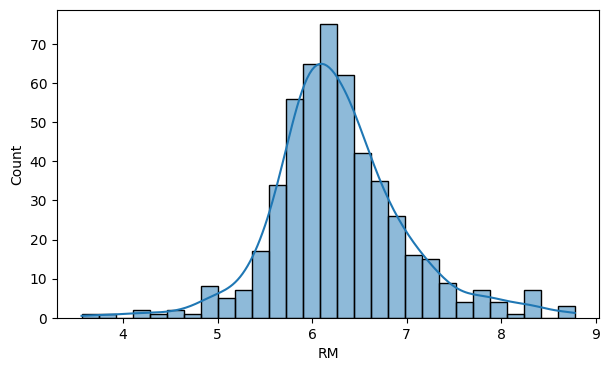

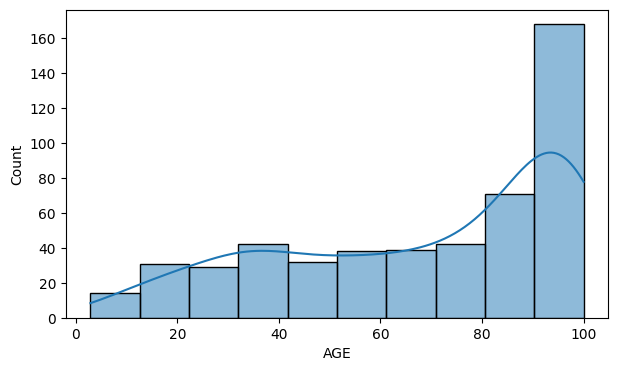

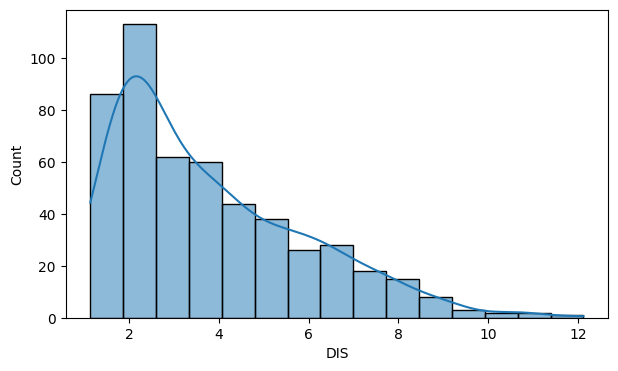

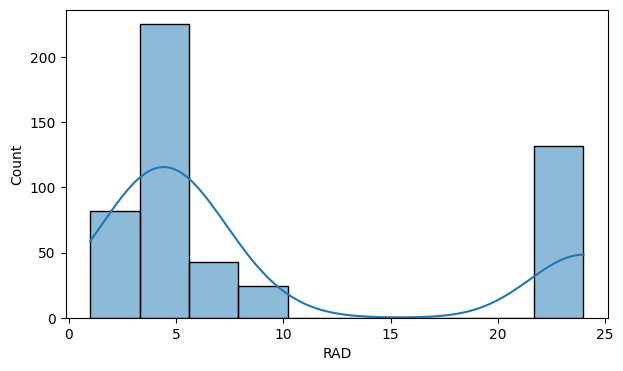

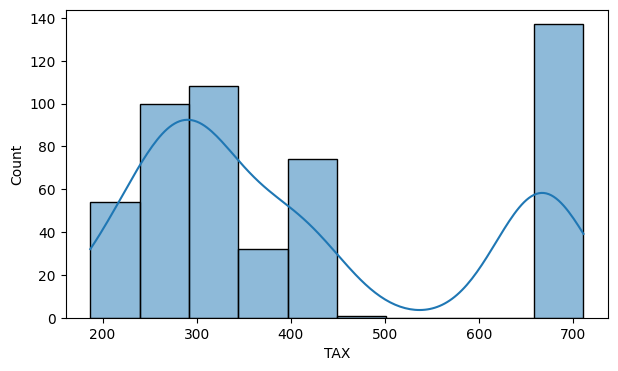

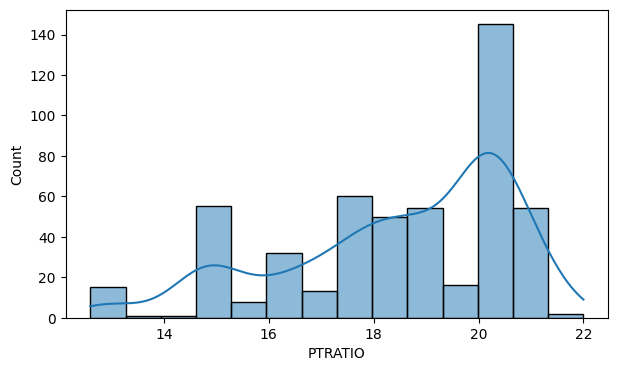

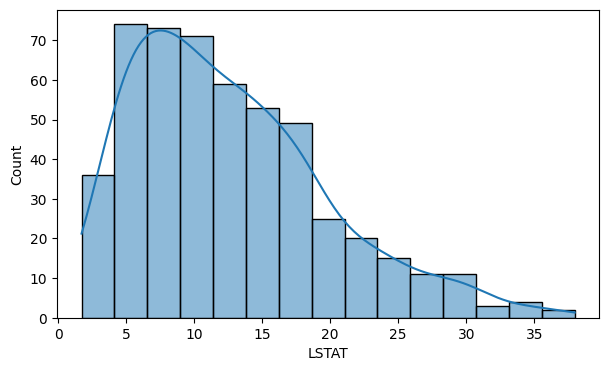

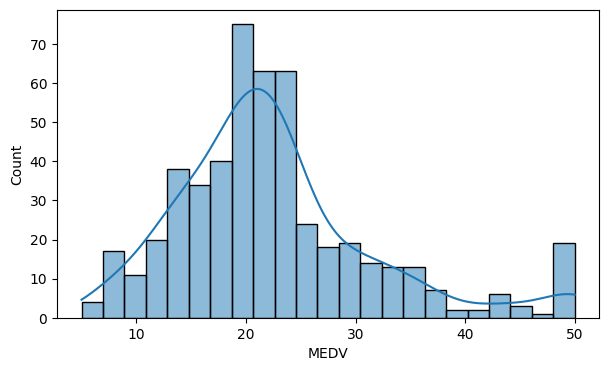

In [ ]:
# Plotting all the columns to look at their distributions
for i in df.columns:

    plt.figure(figsize = (7, 4))
    sns.histplot(data = df, x = i, kde = True)
    plt.show()

**Write your observations here:___________**

As the dependent variable is sightly skewed, we will apply a **log transformation on the 'MEDV' column** and check the distribution of the transformed column.

In [ ]:
df['MEDV_log'] = np.log(df['MEDV'])

<Axes: xlabel='MEDV_log', ylabel='Count'>

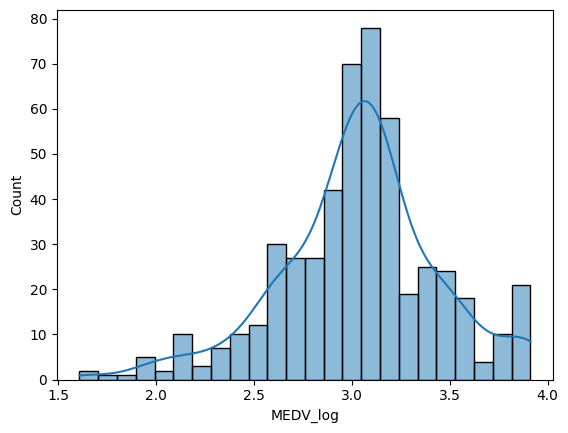

In [ ]:
sns.histplot(data = df, x = 'MEDV_log', kde = True)

**Observation:**

- The log-transformed variable (**MEDV_log**) appears to have a **nearly normal distribution without skew**, and hence we can proceed.

Before creating the linear regression model, it is important to check the bivariate relationship between the variables. Let's check the same using the heatmap and scatterplot.

### **Bivariate Analysis**

**Let's check the correlation using the heatmap**

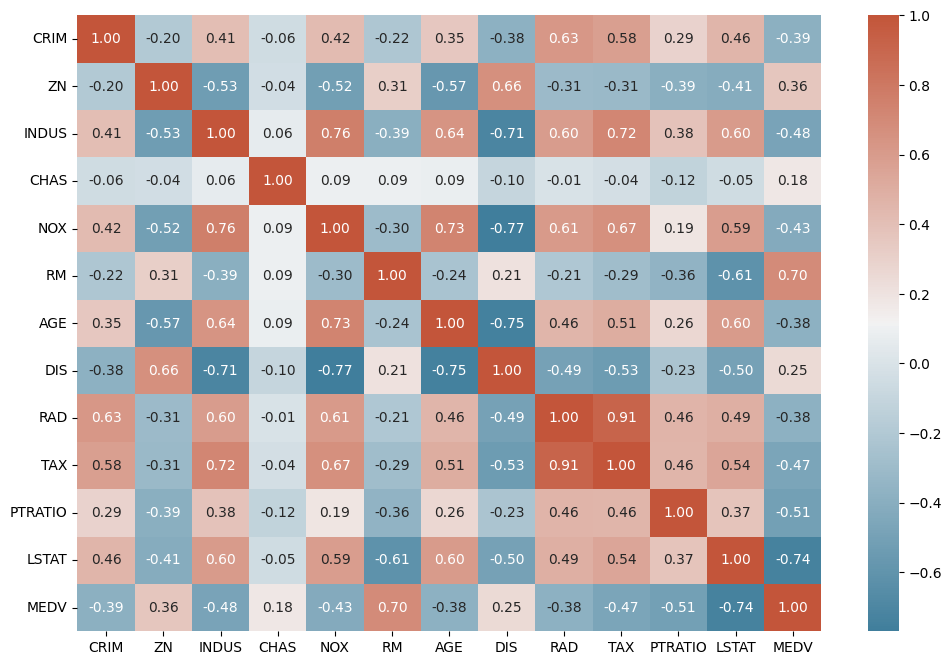

In [ ]:
# Plot heatmap to show correlations between all variables
plt.figure(figsize = (12, 8))
cmap = sns.diverging_palette(230, 20, as_cmap = True)
sns.heatmap(df.corr(), annot = True, fmt = '.2f', cmap = cmap) ## Complete the code
plt.show()

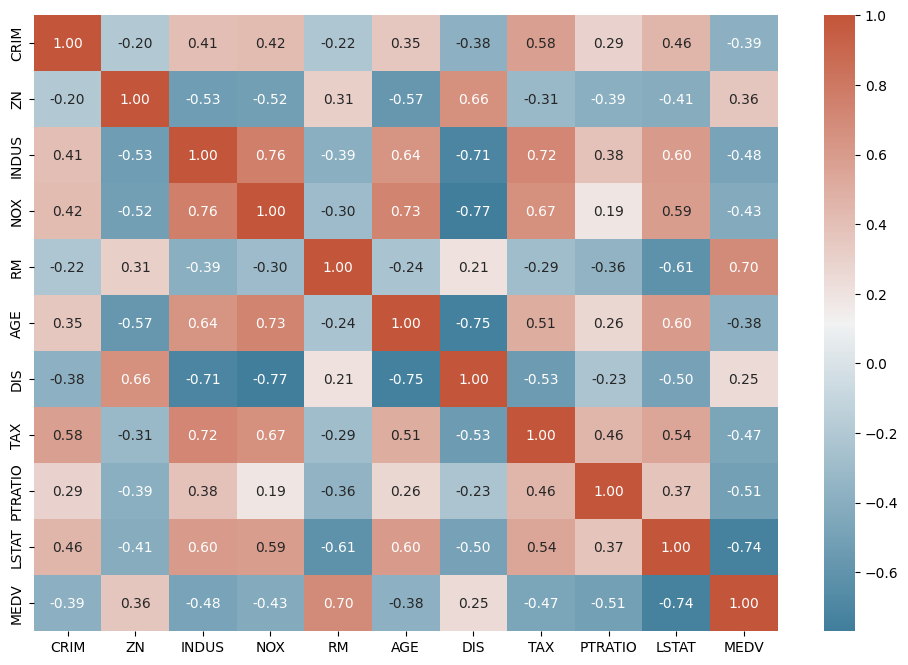

In [ ]:
# Plot heatmap to show correlations between numerical variables
plt.figure(figsize = (12, 8))
cmap = sns.diverging_palette(230, 20, as_cmap = True)
sns.heatmap(df.drop(columns=['CHAS', 'RAD']).corr(), annot = True, fmt = '.2f', cmap = cmap) ## Complete the code
plt.show()

**Write your observations here:___________**

Now, we will visualize the relationship between the pairs of features having significant correlations.

### **Visualizing the relationship between the features having significant correlations (>= 0.7 or <= -0.7)**

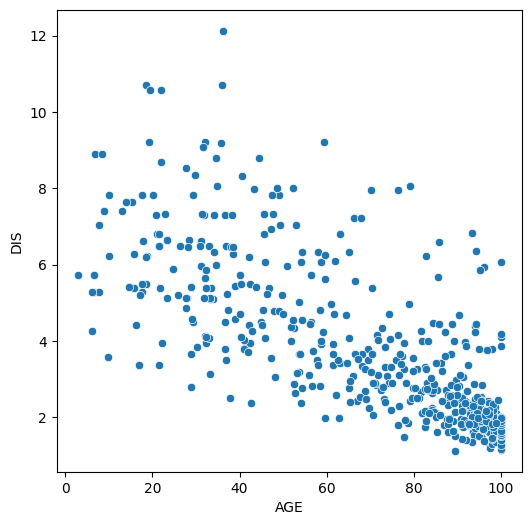

In [ ]:
# Plot Scatterplot to visualize the relationship between AGE and DIS
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'AGE', y = 'DIS', data = df)
plt.show()

**Observations:**
- The distance of the houses to the Boston employment centers appears to decrease moderately as the the proportion of the old houses increase in the town. It is possible that the Boston employment centers are located in the established towns where proportion of owner-occupied units built prior to 1940 is comparatively high.

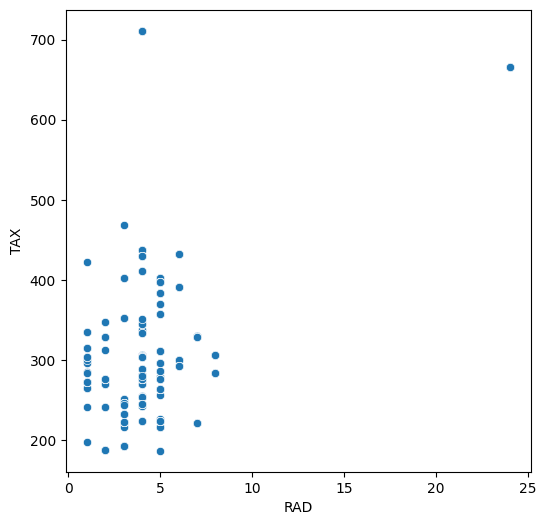

In [ ]:
# Plot Scatterplot to visulaize the relationship between RAD and TAX
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'RAD', y = 'TAX', data = df)
plt.show()

**Observations:**

- The correlation between RAD and TAX is very high. But, no trend is visible between the two variables.
- The strong correlation might be due to outliers.

Let's check the correlation after removing the outliers.

In [ ]:
# Remove the data corresponding to high tax rate
df1 = df[df['TAX'] < 600]

# Import the required function
from scipy.stats import pearsonr

# Calculate the correlation
print("The correlation between TAX and RAD is " + str(round(pearsonr(df1['TAX'], df1['RAD'])[0], 2)) + ".")

The correlation between TAX and RAD is 0.25.


**Observation:**

- So, the high correlation between TAX and RAD is due to the outliers. The tax rate for some properties might be higher due to some other reason.

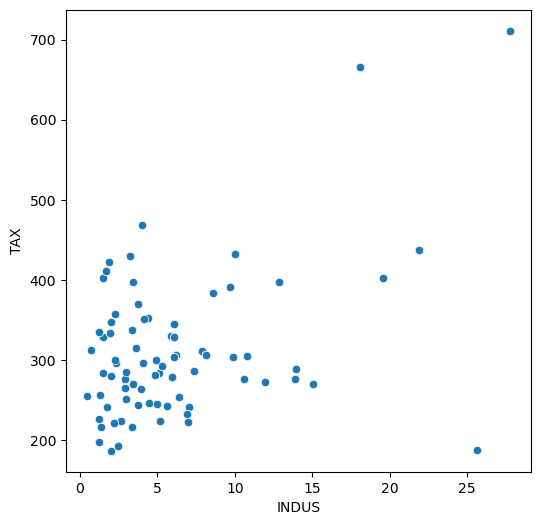

In [ ]:
# Plot Scatterplot to visualize the relationship between INDUS and TAX
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'INDUS', y = 'TAX', data = df)
plt.show()

**Observations:**

- The tax rate appears to increase with an increase in the proportion of non-retail business acres per town. This might be due to the reason that the variables TAX and INDUS are related with a third variable.

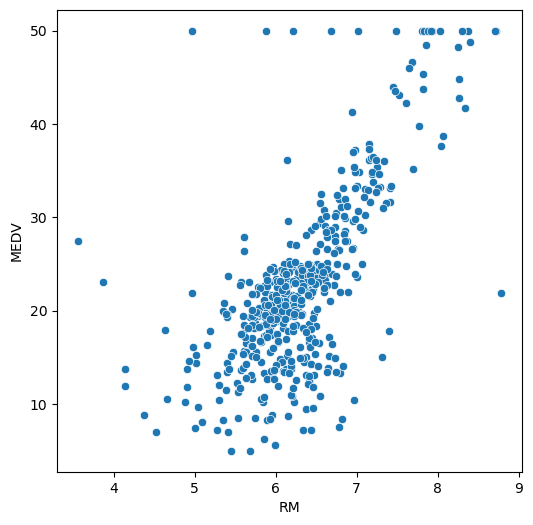

In [ ]:
# Scatterplot to visulaize the relationship between RM and MEDV
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'RM', y = 'MEDV', data = df)
plt.show()

**Observations:**

- The price of the house seems to increase as the value of RM increases. This is expected as the price is generally higher for more rooms.

- There are a few outliers in a horizontal line as the MEDV value seems to be capped at 50.

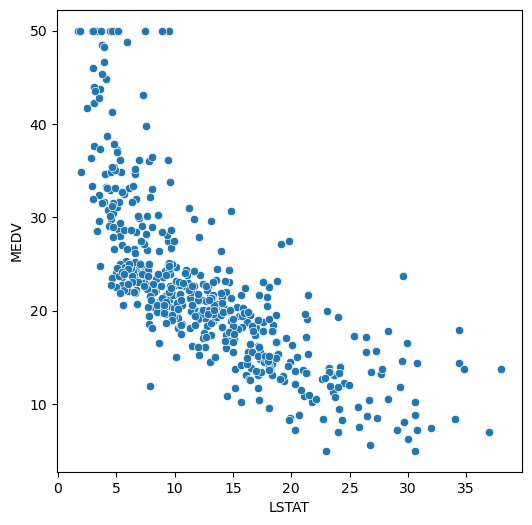

In [ ]:
# Plot Scatterplot to visulaize the relationship between LSTAT and MEDV
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'LSTAT', y = 'MEDV', data = df)
plt.show()

**Observations:**

- The price of the house tends to decrease with an increase in LSTAT. This is also possible as the house price is lower in areas where lower status people live.
- There are few outliers and the data seems to be capped at 50.

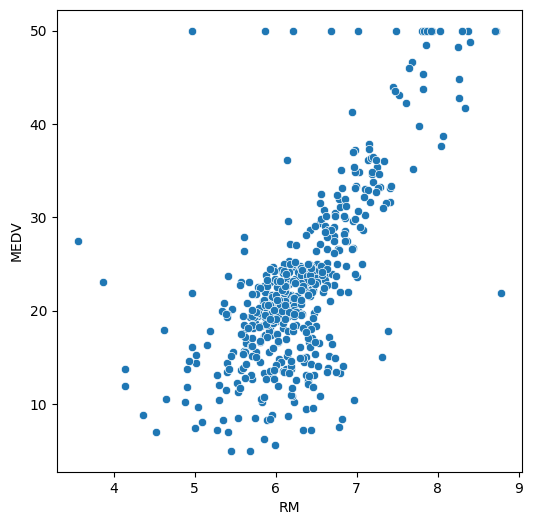

In [ ]:
# Plot Scatterplot to visulaize the relationship between RM and MEDV
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'RM', y = 'MEDV', data = df)
plt.show()

- **Create a scatter plot to visualize the relationship between the remaining features having significant correlations (>= 0.7 or <= -0.7)**
    - INDUS and NOX
    - AGE and NOX
    - DIS and NOX
- **Write your observations from the plots**

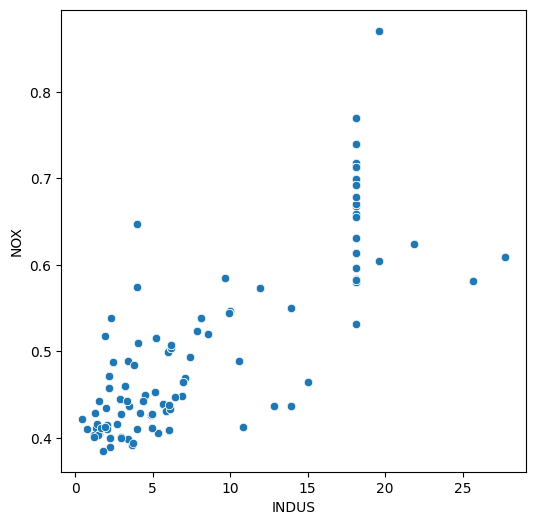

In [ ]:
# Plot Scatterplot to visualize the relationship between INDUS and NOX
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'INDUS', y = 'NOX', data = df)
plt.show()

**Write your observations here:___________**

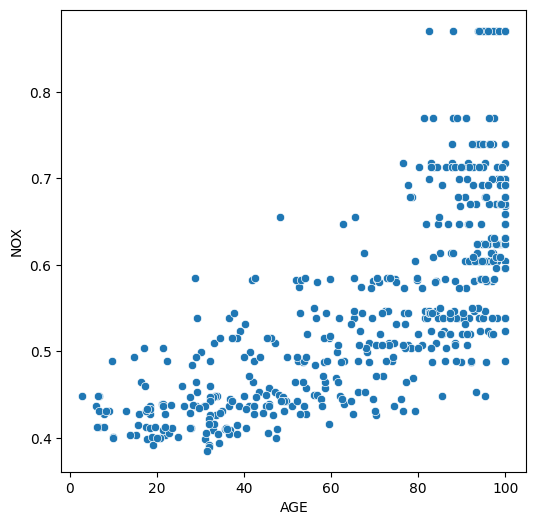

In [ ]:
# Plot Scatterplot to visualize the relationship between AGE and NOX
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'AGE', y = 'NOX', data = df)
plt.show()

**Write your observations here:___________**

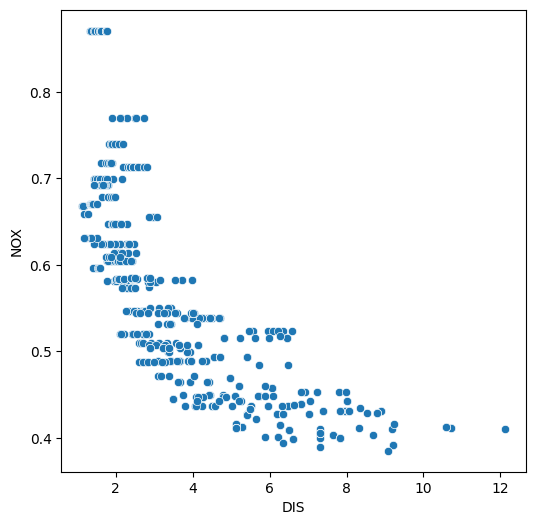

In [ ]:
# Plot Scatterplot to visualize the relationship between DIS and NOX
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'DIS', y = 'NOX', data = df)
plt.show()

**Write your observations here:___________**

We have seen that the variables LSTAT and RM have a linear relationship with the dependent variable MEDV. Also, there are significant relationships among few independent variables, which is not desirable for a linear regression model. Let's first split the dataset.

In [ ]:
# Convert RAD to a categorical variable
df['RAD_cat'] = df['RAD'].astype('category')
# One-hot encode the categories
RAD_dummies = pd.get_dummies(df['RAD_cat'], prefix='RAD', drop_first=True)
# Concatenate back to the dataframe
df = pd.concat([df, RAD_dummies], axis=1)
# Drop original columns
df = df.drop(columns=['RAD', 'RAD_cat'])

In [ ]:
# Convert ZN to a categorical variable
df['ZN_cat'] = df['ZN'].astype('category')
# One-hot encode the categories
ZN_dummies = pd.get_dummies(df['ZN_cat'], prefix='ZN', drop_first=True)
# Concatenate back to the dataframe
df = pd.concat([df, ZN_dummies], axis=1)
# Drop original columns
df = df.drop(columns=['ZN', 'ZN_cat'])

### **Split the dataset**

Let's split the data into the dependent and independent variables and further split it into train and test set in a ratio of 70:30 for train and test sets.

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,...,MEDV,MEDV_log,RAD_2,RAD_3,RAD_4,RAD_5,RAD_6,RAD_7,RAD_8,RAD_24
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,296,15.3,...,24.0,3.178054,False,False,False,False,False,False,False,False
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,242,17.8,...,21.6,3.072693,True,False,False,False,False,False,False,False
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,242,17.8,...,34.7,3.546740,True,False,False,False,False,False,False,False
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,222,18.7,...,33.4,3.508556,False,True,False,False,False,False,False,False
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,222,18.7,...,36.2,3.589059,False,True,False,False,False,False,False,False


In [ ]:
# Separate the features (independent variables) and target column (dependent variable)
Y = df['MEDV_log']
X = df.drop(columns = {'MEDV', 'MEDV_log'})
# Add the intercept term
X = sm.add_constant(X)

In [ ]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [ ]:
Y.head()

,MEDV_log
0,3.178054
1,3.072693
2,3.546740
3,3.508556
4,3.589059


In [ ]:
X.head()

,const,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,RAD_2,RAD_3,RAD_4,RAD_5,RAD_6,RAD_7,RAD_8,RAD_24
0,1.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,296,15.3,4.98,0,0,0,0,0,0,0,0
1,1.0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,242,17.8,9.14,1,0,0,0,0,0,0,0
2,1.0,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,242,17.8,4.03,1,0,0,0,0,0,0,0
3,1.0,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,222,18.7,2.94,0,1,0,0,0,0,0,0
4,1.0,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,222,18.7,5.33,0,1,0,0,0,0,0,0


In [ ]:
# Splitting the data into an 80:20 ratio of train to test data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.20, random_state = 1)

In [ ]:
# Compute X_train rows and columns
X_train.shape

(404, 20)

In [ ]:
# Compute X_test rows and columns
X_test.shape

(102, 20)

Next, we will check the multicollinearity in the training dataset.

### **Check for Multicollinearity**

We will use the Variance Inflation Factor (VIF), to check if there is multicollinearity in the data.

Features having a VIF score > 5 will be dropped / treated till all the features have a VIF score < 5

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def checking_vif(train):
    """
    Computes VIF for all numeric columns in the training set and
    flags features with high, infinite, or NaN VIF values.
    """

    # Ensure boolean columns are converted to int (safety check)
    bool_cols = train.select_dtypes(include='bool').columns
    if len(bool_cols) > 0:
        train = train.copy()
        train[bool_cols] = train[bool_cols].astype(int)

    # Compute VIF
    vif_df = pd.DataFrame()
    vif_df["feature"] = train.columns
    vif_df["VIF"] = [
        variance_inflation_factor(train.values, i)
        for i in range(len(train.columns))
    ]

    # Diagnostic flags
    vif_df["is_nan"] = vif_df["VIF"].isna()
    vif_df["is_inf"] = np.isinf(vif_df["VIF"])
    vif_df["gt_5"] = vif_df["VIF"] > 5
    vif_df["gt_10"] = vif_df["VIF"] > 10

    # Print summary of problematic features
    print("\n=== VIF Diagnostics ===")

    print("\nFeatures with VIF > 5:")
    print(vif_df[vif_df["gt_5"] & ~vif_df["is_inf"] & ~vif_df["is_nan"]][["feature", "VIF"]])

    print("\nFeatures with VIF > 10:")
    print(vif_df[vif_df["gt_10"] & ~vif_df["is_inf"] & ~vif_df["is_nan"]][["feature", "VIF"]])

    print("\nFeatures with infinite VIF:")
    print(vif_df[vif_df["is_inf"]][["feature", "VIF"]])

    print("\nFeatures with NaN VIF:")
    print(vif_df[vif_df["is_nan"]][["feature", "VIF"]])

    return vif_df


In [ ]:
vif_table = checking_vif(X_train)


=== VIF Diagnostics ===

Features with VIF > 5:
   feature         VIF
0    const  631.374831
9      TAX   10.745022
14   RAD_4    5.864641
15   RAD_5    6.405854
19  RAD_24   15.627482

Features with VIF > 10:
   feature         VIF
0    const  631.374831
9      TAX   10.745022
19  RAD_24   15.627482

Features with infinite VIF:
Empty DataFrame
Columns: [feature, VIF]
Index: []

Features with NaN VIF:
Empty DataFrame
Columns: [feature, VIF]
Index: []


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Function to check VIF
def checking_vif(train):
    vif = pd.DataFrame()
    vif["feature"] = train.columns

    # Calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(train.values, i) for i in range(len(train.columns))
    ]
    return vif

# Convert boolean columns to integer (0 or 1) before calculating VIF
# Identify boolean columns
bool_cols = X_train.select_dtypes(include='bool').columns
X_train_numeric = X_train.copy()
for col in bool_cols:
    X_train_numeric[col] = X_train_numeric[col].astype(int)


print(checking_vif(X_train_numeric))

    feature         VIF
0     const  631.374831
1      CRIM    1.743204
2        ZN    2.751841
3     INDUS    4.242444
4      CHAS    1.123667
5       NOX    4.681140
6        RM    1.993810
7       AGE    3.325811
8       DIS    4.426762
9       TAX   10.745022
10  PTRATIO    2.347767
11    LSTAT    3.046615
12    RAD_2    2.569169
13    RAD_3    3.077516
14    RAD_4    5.864641
15    RAD_5    6.405854
16    RAD_6    2.545689
17    RAD_7    2.047015
18    RAD_8    2.362674
19   RAD_24   15.627482


In [ ]:

def checking_vif(train):
    vif = pd.DataFrame()
    vif["feature"] = train.columns

    # Calculate VIF values
    vif_values = [
        variance_inflation_factor(train.values, i)
        for i in range(len(train.columns))
    ]
    vif["VIF"] = vif_values

    # Add diagnostic flags
    vif["is_nan"] = vif["VIF"].isna()
    vif["is_inf"] = np.isinf(vif["VIF"])
    vif["gt_5"] = vif["VIF"] > 5
    vif["gt_10"] = vif["VIF"] > 10

    return vif

In [ ]:
# Drop RAD_24 variable and check for updated VIF score
X_train = X_train.drop('RAD_24', axis = 1)

# Convert boolean columns to integer (0 or 1) before calculating VIF for the modified X_train
bool_cols = X_train.select_dtypes(include='bool').columns
X_train_numeric_for_vif = X_train.copy()
for col in bool_cols:
    X_train_numeric_for_vif[col] = X_train_numeric_for_vif[col].astype(int)

# Check for VIF
print(checking_vif(X_train_numeric_for_vif))

    feature         VIF
0     const  620.588899
1      CRIM    1.679807
2        ZN    2.665206
3     INDUS    4.088055
4      CHAS    1.118239
5       NOX    4.638782
6        RM    1.970336
7       AGE    3.310113
8       DIS    4.426292
9       TAX    6.056368
10  PTRATIO    2.317589
11    LSTAT    3.035260
12    RAD_2    2.181809
13    RAD_3    2.442372
14    RAD_4    3.410829
15    RAD_5    3.801857
16    RAD_6    1.605026
17    RAD_7    1.568032
18    RAD_8    1.738170


In [ ]:
# Drop TAX variable and check for updated VIF score
X_train = X_train.drop('TAX', axis = 1)

# Convert boolean columns to integer (0 or 1) before calculating VIF for the modified X_train
bool_cols = X_train.select_dtypes(include='bool').columns
X_train_numeric_for_vif = X_train.copy()
for col in bool_cols:
    X_train_numeric_for_vif[col] = X_train_numeric_for_vif[col].astype(int)

# Check for VIF
print(checking_vif(X_train_numeric_for_vif))

    feature         VIF
0     const  620.124729
1      CRIM    1.636211
2        ZN    2.614195
3     INDUS    3.476529
4      CHAS    1.108493
5       NOX    4.515714
6        RM    1.957092
7       AGE    3.310112
8       DIS    4.423749
9   PTRATIO    2.201472
10    LSTAT    3.032208
11    RAD_2    1.515215
12    RAD_3    1.779928
13    RAD_4    2.136819
14    RAD_5    2.748988
15    RAD_6    1.461392
16    RAD_7    1.384117
17    RAD_8    1.506059


In [ ]:
# Drop RAD_24 and TAX variables in X_test
X_test = X_test.drop('RAD_24', axis = 1)
X_test = X_test.drop('TAX', axis = 1)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404 entries, 42 to 37
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   const    404 non-null    float64
 1   CRIM     404 non-null    float64
 2   ZN       404 non-null    float64
 3   INDUS    404 non-null    float64
 4   CHAS     404 non-null    int64  
 5   NOX      404 non-null    float64
 6   RM       404 non-null    float64
 7   AGE      404 non-null    float64
 8   DIS      404 non-null    float64
 9   PTRATIO  404 non-null    float64
 10  LSTAT    404 non-null    float64
 11  RAD_2    404 non-null    bool   
 12  RAD_3    404 non-null    bool   
 13  RAD_4    404 non-null    bool   
 14  RAD_5    404 non-null    bool   
 15  RAD_6    404 non-null    bool   
 16  RAD_7    404 non-null    bool   
 17  RAD_8    404 non-null    bool   
dtypes: bool(7), float64(10), int64(1)
memory usage: 40.6 KB


In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102 entries, 307 to 443
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   const    102 non-null    float64
 1   CRIM     102 non-null    float64
 2   ZN       102 non-null    float64
 3   INDUS    102 non-null    float64
 4   CHAS     102 non-null    int64  
 5   NOX      102 non-null    float64
 6   RM       102 non-null    float64
 7   AGE      102 non-null    float64
 8   DIS      102 non-null    float64
 9   PTRATIO  102 non-null    float64
 10  LSTAT    102 non-null    float64
 11  RAD_2    102 non-null    bool   
 12  RAD_3    102 non-null    bool   
 13  RAD_4    102 non-null    bool   
 14  RAD_5    102 non-null    bool   
 15  RAD_6    102 non-null    bool   
 16  RAD_7    102 non-null    bool   
 17  RAD_8    102 non-null    bool   
dtypes: bool(7), float64(10), int64(1)
memory usage: 10.3 KB


In [ ]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 404 entries, 42 to 37
Series name: MEDV_log
Non-Null Count  Dtype  
--------------  -----  
404 non-null    float64
dtypes: float64(1)
memory usage: 6.3 KB


In [ ]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 102 entries, 307 to 443
Series name: MEDV_log
Non-Null Count  Dtype  
--------------  -----  
102 non-null    float64
dtypes: float64(1)
memory usage: 1.6 KB


In [ ]:
# Convert boolean columns to integer (0 or 1) for X_train
bool_cols_train = X_train.select_dtypes(include='bool').columns
for col in bool_cols_train:
    X_train[col] = X_train[col].astype(int)

# Convert boolean columns to integer (0 or 1) for X_test
bool_cols_test = X_test.select_dtypes(include='bool').columns
for col in bool_cols_test:
    X_test[col] = X_test[col].astype(int)

# Create the model
model1 = sm.OLS(y_train, X_train).fit()
# Get the model summary
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               MEDV_log   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     80.57
Date:                Sat, 28 Feb 2026   Prob (F-statistic):          1.98e-115
Time:                        18:28:52   Log-Likelihood:                 98.645
No. Observations:                 404   AIC:                            -161.3
Df Residuals:                     386   BIC:                            -89.26
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2989      0.240     17.893      0.000       3.827       4.771
CRIM          -0.0098      0.001     -7.238      0.000      -0.012      -0.007
ZN             0.0013      0.001      1.953      0.052   -8.76e-06       0.003
INDUS          0.0002      0.003      0.063      0.950      -0.005       0.005
CHAS           0.1049      0.038      2.790      0.006       0.031       0.179
NOX           -0.8391      0.176     -4.779      0.000      -1.184      -0.494
RM             0.0718      0.020      3.663      0.000       0.033       0.110
AGE            0.0004      0.001      0.651      0.516      -0.001       0.002
DIS           -0.0523      0.010     -5.461      0.000      -0.071      -0.033
PTRATIO       -0.0365      0.007     -5.521      0.000      -0.049      -0.023
LSTAT         -0.0297      0.002    -12.750      0.000      -0.034      -0.025
RAD_2         -0.0126      0.052     -0.240      0.810      -0.115       0.090
RAD_3          0.0573      0.048      1.202      0.230      -0.036       0.151
RAD_4         -0.0466      0.035     -1.348      0.178      -0.115       0.021
RAD_5         -0.0225      0.038     -0.589      0.556      -0.097       0.053
RAD_6         -0.0874      0.053     -1.664      0.097      -0.191       0.016
RAD_7          0.0665      0.060      1.108      0.269      -0.052       0.185
RAD_8          0.0107      0.057      0.186      0.852      -0.102       0.124
==============================================================================
Omnibus:                       45.563   Durbin-Watson:                   1.948
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              179.647
Skew:                           0.395   Prob(JB):                     9.78e-40
Kurtosis:                       6.170   Cond. No.                     2.16e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.16e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
from sklearn.metrics import r2_score

# RMSE
def rmse(predictions, targets):
    return np.sqrt(((targets - predictions) ** 2).mean())


# MAPE
def mape(predictions, targets):
    return np.mean(np.abs((targets - predictions)) / targets) * 100


# MAE
def mae(predictions, targets):
    return np.mean(np.abs((targets - predictions)))


# Model Performance on test and train data
def model_pref(olsmodel, x_train, x_test):

    # In-sample Prediction
    y_pred_train = olsmodel.predict(x_train)
    y_observed_train = y_train

    # Prediction on test data
    y_pred_test = olsmodel.predict(x_test)
    y_observed_test = y_test

    print(
        pd.DataFrame(
            {
                "Data": ["Train", "Test"],
                "RMSE": [
                    rmse(y_pred_train, y_observed_train),
                    rmse(y_pred_test, y_observed_test),
                ],
                "MAE": [
                    mae(y_pred_train, y_observed_train),
                    mae(y_pred_test, y_observed_test),
                ],
                "MAPE": [
                    mape(y_pred_train, y_observed_train),
                    mape(y_pred_test, y_observed_test),
                ],
                "r2": [
                    r2_score(y_pred_train, y_observed_train),
                    r2_score(y_pred_test, y_observed_test),
                ],
            }
        )
    )


# Checking model performance
model_pref(model1, X_train, X_test)

    Data      RMSE       MAE      MAPE        r2
0  Train  0.189549  0.134353  4.671885  0.718177
1   Test  0.205496  0.155262  5.441155  0.615417


In [ ]:
# RMSE
def rmse(predictions, targets):
    return np.sqrt(((targets - predictions) ** 2).mean())


# MAPE
def mape(predictions, targets):
    return np.mean(np.abs((targets - predictions)) / targets) * 100


# MAE
def mae(predictions, targets):
    return np.mean(np.abs((targets - predictions)))


# Model Performance on test and train data
def model_pref2(olsmodel, x_train, x_test):

    # In-sample Prediction
    y_pred_train = olsmodel.predict(x_train)
    y_observed_train = y_train

    # Prediction on test data
    y_pred_test = olsmodel.predict(x_test)
    y_observed_test = y_test

    print(
        pd.DataFrame(
            {
                "Data": ["Train", "Test"],
                "RMSE": [
                    rmse(y_pred_train, y_observed_train),
                    rmse(y_pred_test, y_observed_test),
                ],
                "MAE": [
                    mae(y_pred_train, y_observed_train),
                    mae(y_pred_test, y_observed_test),
                ],
                "MAPE": [
                    mape(y_pred_train, y_observed_train),
                    mape(y_pred_test, y_observed_test),
                ],
            }
        )
    )

In [ ]:
# Checking model1 performance
model_pref(model1, X_train, X_test)

    Data      RMSE       MAE      MAPE        r2
0  Train  0.189549  0.134353  4.671885  0.718177
1   Test  0.205496  0.155262  5.441155  0.615417


**Observations:**

- There are two variables with a high VIF - RAD and TAX (greater than 5).
- Let's remove TAX as it has the highest VIF values and check the multicollinearity again.

Now, we will create the linear regression model as the VIF is less than 5 for all the independent variables, and we can assume that multicollinearity has been removed between the variables.

**Hint:** Use the sm.OLS() model on the training data

In [ ]:
X_train = X_train.drop(['INDUS', 'AGE', 'ZN', 'RAD_2', 'RAD_3', 'RAD_4', 'RAD_5', 'RAD_6', 'RAD_7', 'RAD_8'], axis = 1)

In [ ]:
# Drop all independent variables or features with p-values greater than 0.05 on X train and X test model2
X_train = X_train.drop(['INDUS', 'AGE', 'ZN', 'RAD_2', 'RAD_3', 'RAD_4', 'RAD_5', 'RAD_6', 'RAD_7', 'RAD_8'], axis = 1)
X_test = X_test.drop(['INDUS', 'AGE', 'ZN', 'RAD_2', 'RAD_3', 'RAD_4', 'RAD_5', 'RAD_6', 'RAD_7', 'RAD_8'], axis = 1)

In [ ]:
X_test = X_test.drop(['INDUS', 'AGE', 'ZN', 'RAD_2', 'RAD_3', 'RAD_4', 'RAD_5', 'RAD_6', 'RAD_7', 'RAD_8'], axis = 1)

In [ ]:
# Drop all independent variables or features with p-values greater than 0.05 on X train and X test model3
X_train = X_train.drop(['INDUS', 'AGE', 'RAD_2', 'RAD_3', 'RAD_4', 'RAD_5', 'RAD_6', 'RAD_7', 'RAD_8'], axis = 1)
X_test = X_test.drop(['INDUS', 'AGE', 'RAD_2', 'RAD_3', 'RAD_4', 'RAD_5', 'RAD_6', 'RAD_7', 'RAD_8'], axis = 1)

**Write your observations here:___________**

### **Examining the significance of the model**

It is not enough to fit a multiple regression model to the data, it is necessary to check whether all the regression coefficients are significant or not. Significance here means whether the population regression parameters are significantly different from zero.

From the above it may be noted that the regression coefficients corresponding to ZN, AGE, and INDUS are not statistically significant at level α = 0.05. In other words, the regression coefficients corresponding to these three are not significantly different from 0 in the population. Hence, we will eliminate the three features and create a new model.

In [ ]:
# Create the model
model2 = sm.OLS(y_train, X_train).fit()
# Get the model summary
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               MEDV_log   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     190.4
Date:                Sat, 28 Feb 2026   Prob (F-statistic):          1.60e-122
Time:                        16:21:57   Log-Likelihood:                 90.399
No. Observations:                 404   AIC:                            -164.8
Df Residuals:                     396   BIC:                            -132.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1437      0.205     20.221      0.000       3.741       4.547
CRIM          -0.0087      0.001     -7.036      0.000      -0.011      -0.006
CHAS           0.1070      0.037      2.897      0.004       0.034       0.180
NOX           -0.7785      0.143     -5.463      0.000      -1.059      -0.498
RM             0.0911      0.018      4.929      0.000       0.055       0.127
DIS           -0.0418      0.007     -5.748      0.000      -0.056      -0.027
PTRATIO       -0.0376      0.005     -7.413      0.000      -0.048      -0.028
LSTAT         -0.0290      0.002    -13.535      0.000      -0.033      -0.025
==============================================================================
Omnibus:                       56.955   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              213.493
Skew:                           0.563   Prob(JB):                     4.37e-47
Kurtosis:                       6.379   Cond. No.                         562.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Checking model2 performance
model_pref(model2, X_train, X_test)

    Data      RMSE       MAE      MAPE        r2
0  Train  0.193457  0.138025  4.782150  0.702947
1   Test  0.205768  0.157446  5.515539  0.616398


In [ ]:
# Create the model - model3
model2 = sm.OLS(y_train, X_train).fit()
# Get the model summary
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               MEDV_log   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     168.1
Date:                Sat, 28 Feb 2026   Prob (F-statistic):          4.11e-122
Time:                        18:32:11   Log-Likelihood:                 92.164
No. Observations:                 404   AIC:                            -166.3
Df Residuals:                     395   BIC:                            -130.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1539      0.204     20.326      0.000       3.752       4.556
CRIM          -0.0091      0.001     -7.270      0.000      -0.012      -0.007
ZN             0.0012      0.001      1.862      0.063   -6.57e-05       0.002
CHAS           0.1079      0.037      2.931      0.004       0.036       0.180
NOX           -0.7867      0.142     -5.535      0.000      -1.066      -0.507
RM             0.0851      0.019      4.549      0.000       0.048       0.122
DIS           -0.0507      0.009     -5.839      0.000      -0.068      -0.034
PTRATIO       -0.0346      0.005     -6.519      0.000      -0.045      -0.024
LSTAT         -0.0291      0.002    -13.625      0.000      -0.033      -0.025
==============================================================================
Omnibus:                       52.463   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              197.176
Skew:                           0.506   Prob(JB):                     1.53e-43
Kurtosis:                       6.270   Cond. No.                         673.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Create the model after dropping columns 'MEDV', 'MEDV_log', 'TAX', 'ZN', 'AGE', 'INDUS' from df DataFrame
Y = df['MEDV_log']

X = df.drop(________________) # Complete the code

X = sm.add_constant(X)

# Splitting the data in 70:30 ratio of train to test data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.20 , random_state = 1)

# Create the model
model2 = sm.OLS(_____, ______).fit()  ## Complete the code

# Get the model summary
model2.summary()

Now, we will check the linear regression assumptions.

### **Checking the below linear regression assumptions**

1. **Mean of residuals should be 0**
2. **No Heteroscedasticity**
3. **Linearity of variables**
4. **Normality of error terms**

### **1. Check for mean residuals**

In [ ]:
residuals = ______  ## Complete the code

np.mean(residuals)

In [ ]:
residuals = model2.resid #model2
np.mean(residuals)

np.float64(-4.8052870813355164e-15)

In [ ]:
residuals = model1.resid #model1
np.mean(residuals)

np.float64(7.590737719355463e-15)

**Write your observations here:___________**

### **2. Check for homoscedasticity**

- Homoscedasticity - If the residuals are symmetrically distributed across the regression line, then the data is said to be homoscedastic.

- Heteroscedasticity- - If the residuals are not symmetrically distributed across the regression line, then the data is said to be heteroscedastic. In this case, the residuals can form a funnel shape or any other non-symmetrical shape.

- We'll use `Goldfeldquandt Test` to test the following hypothesis with alpha = 0.05:

    - Null hypothesis: Residuals are homoscedastic
    - Alternate hypothesis: Residuals have heteroscedastic

In [ ]:
from statsmodels.stats.diagnostic import het_white

from statsmodels.compat import lzip

import statsmodels.stats.api as sms

In [ ]:
name = ["F statistic", "p-value"]

test = sms.het_goldfeldquandt(___, ____) ## Complete the code

lzip(name, test)

In [ ]:
# Check for homoscedasticity using Goldfeld Quandt test model2
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(y_train, X_train)
lzip(name, test)

[('F statistic', np.float64(1.0880964374565942)),
 ('p-value', np.float64(0.2785544698968608))]

In [ ]:
# Check for homoscedasticity using Goldfeld Quandt test model1
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(y_train, X_train)
lzip(name, test)

[('F statistic', np.float64(1.0562598229862872)),
 ('p-value', np.float64(0.355431142255574))]

**Write your observations here:___________**

### **3. Linearity of variables**

It states that the predictor variables must have a linear relation with the dependent variable.

To test the assumption, we'll plot residuals and the fitted values on a plot and ensure that residuals do not form a strong pattern. They should be randomly and uniformly scattered on the x-axis.

In [ ]:
# Predicted values
fitted = model2.fittedvalues

# sns.set_style("whitegrid")
sns.residplot(x =  y = ________, color = "lightblue", lowess = True)  ## Complete the code

plt.xlabel("Fitted Values")

plt.ylabel("Residual")

plt.title("Residual PLOT")

plt.show()

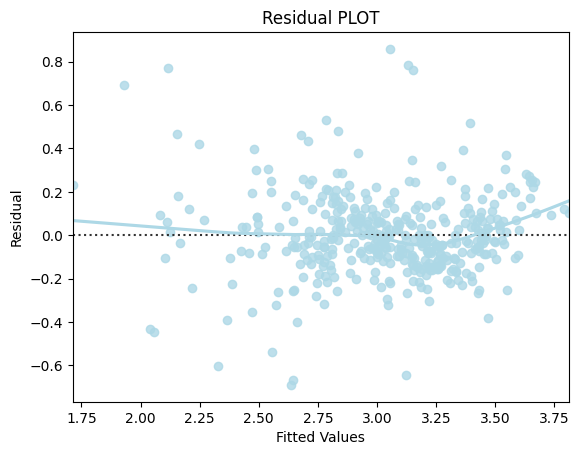

In [ ]:
# Plot residuals model2
fitted = model2.fittedvalues
sns.residplot(x = fitted, y = residuals, color = "lightblue", lowess = True)
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual PLOT")
plt.show()

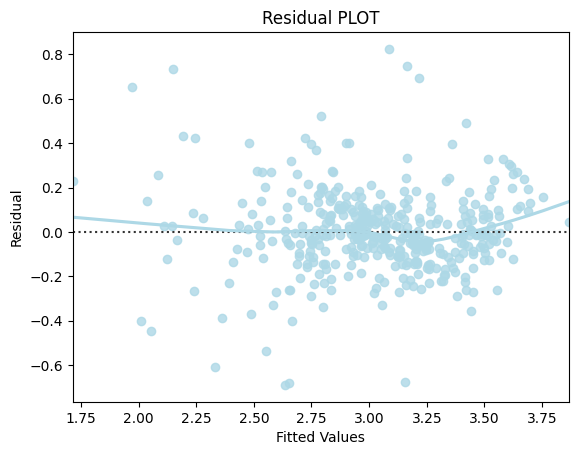

In [ ]:
# Plot residuals model1
fitted = model1.fittedvalues
sns.residplot(x = fitted, y = residuals, color = "lightblue", lowess = True)
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual PLOT")
plt.show()

**Write your observations here:___________**

### **4. Normality of error terms**

The residuals should be normally distributed.

In [ ]:
# Plot histogram of residuals

## Complete the code

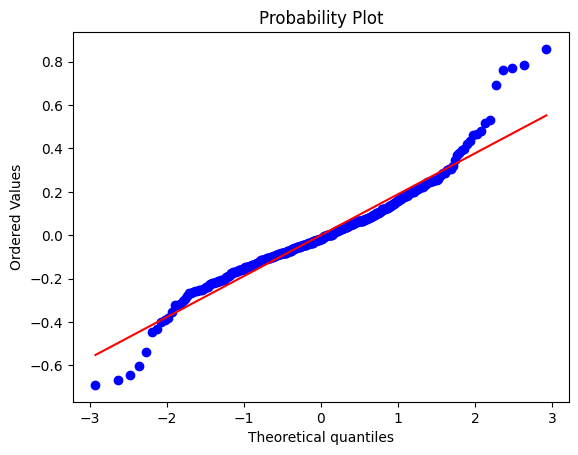

In [ ]:
# Plot q-q plot of residuals model2
import pylab
import scipy.stats as stats
stats.probplot(residuals, dist = "norm", plot = pylab)
plt.show()

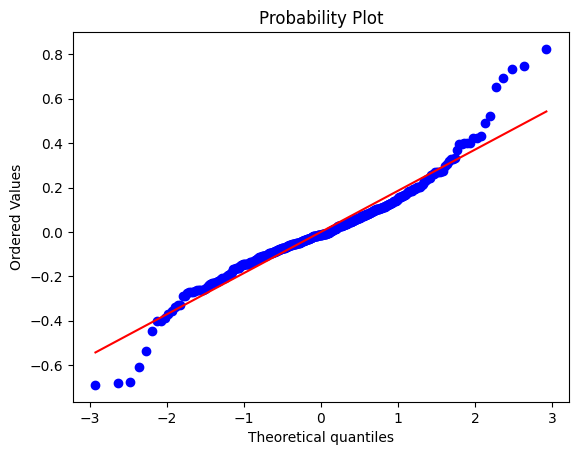

In [ ]:
# Plot q-q plot of residuals model1
import pylab
import scipy.stats as stats
stats.probplot(residuals, dist = "norm", plot = pylab)
plt.show()

In [ ]:
# Plot q-q plot of residuals model2
stats.probplot(residuals, dist = "norm", plot = pylab)
plt.show()

<Axes: ylabel='Count'>

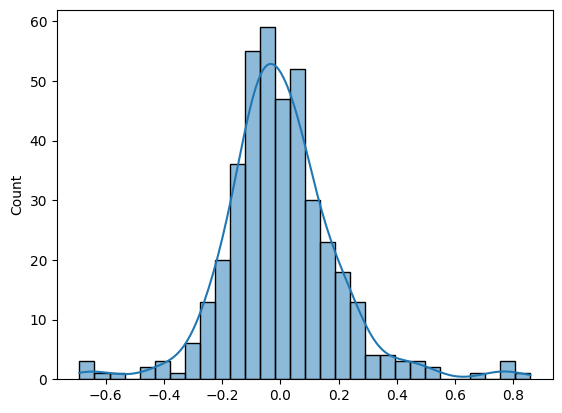

In [ ]:
# Plot histogram of residuals model2
sns.histplot(residuals, kde = True)

<Axes: ylabel='Count'>

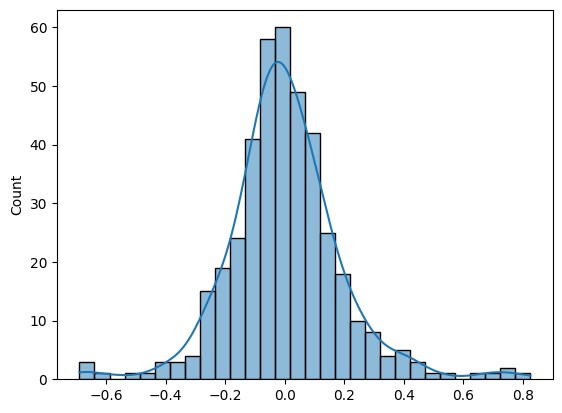

In [ ]:
# Plot histogram of residuals model1
sns.histplot(residuals, kde = True)

**Write your observations here:___________**

### **Check the performance of the model on the train and test data set**

In [ ]:
from sklearn.metrics import r2_score

# RMSE
def rmse(predictions, targets):
    return np.sqrt(((targets - predictions) ** 2).mean())


# MAPE
def mape(predictions, targets):
    return np.mean(np.abs((targets - predictions)) / targets) * 100


# MAE
def mae(predictions, targets):
    return np.mean(np.abs((targets - predictions)))


# Model Performance on test and train data
def model_pref(olsmodel, x_train, x_test):

    # In-sample Prediction
    y_pred_train = olsmodel.predict(x_train)
    y_observed_train = y_train

    # Prediction on test data
    y_pred_test = olsmodel.predict(x_test)
    y_observed_test = y_test

    print(
        pd.DataFrame(
            {
                "Data": ["Train", "Test"],
                "RMSE": [
                    rmse(y_pred_train, y_observed_train),
                    rmse(y_pred_test, y_observed_test),
                ],
                "MAE": [
                    mae(y_pred_train, y_observed_train),
                    mae(y_pred_test, y_observed_test),
                ],
                "MAPE": [
                    mape(y_pred_train, y_observed_train),
                    mape(y_pred_test, y_observed_test),
                ],
                "r2": [
                    r2_score(y_pred_train, y_observed_train),
                    r2_score(y_pred_test, y_observed_test),
                ],
            }
        )
    )


# Checking model performance
model_pref(model2, X_train, X_test)

    Data      RMSE       MAE      MAPE        r2
0  Train  0.193457  0.138025  4.782150  0.702947
1   Test  0.205768  0.157446  5.515539  0.616398


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

# Model Performance on test and train data
def model_pref2(olsmodel, x_train, x_test):

    # In-sample Prediction
    y_pred_train = olsmodel.predict(x_train)
    y_observed_train = y_train

    # Prediction on test data
    y_pred_test = olsmodel.predict(x_test)
    y_observed_test = y_test

    print(
        pd.DataFrame(
            {
                "Data": ["Train", "Test"],
                "RMSE": [
                    np.sqrt(mean_squared_error(y_pred_train, y_observed_train)),
                    np.sqrt(mean_squared_error(y_pred_test, y_observed_test)),
                ],
                "MAE": [
                    mean_absolute_error(y_pred_train, y_observed_train),
                    mean_absolute_error(y_pred_test, y_observed_test),
                ],

                "r2": [
                    r2_score(y_pred_train, y_observed_train),
                    r2_score(y_pred_test, y_observed_test),
                ],
            }
        )
    )

In [ ]:
model_pref2(model2, X_train, X_test)

    Data      RMSE       MAE        r2
0  Train  0.193457  0.138025  0.702947
1   Test  0.205768  0.157446  0.616398


**Write your observations here:___________**

### **Apply cross validation to improve the model and evaluate it using different evaluation metrics**

In [ ]:
# Import the required function model2
from sklearn.model_selection import cross_val_score

# Build the regression model and cross-validate
linearregression = LinearRegression()

cv_Score11 = cross_val_score(linearregression, X_train, y_train, cv = 10)
cv_Score12 = cross_val_score(linearregression, X_train, y_train, cv = 10,
                             scoring = 'neg_mean_squared_error')


print("RSquared: %0.3f (+/- %0.3f)" % (cv_Score11.mean(), cv_Score11.std() * 2))
print("Mean Squared Error: %0.3f (+/- %0.3f)" % (-1*cv_Score12.mean(), cv_Score12.std() * 2))

RSquared: 0.729 (+/- 0.239)
Mean Squared Error: 0.040 (+/- 0.023)


In [ ]:
# Build the regression model and cross-validate
linearregression = LinearRegression()

cv_Score11 = cross_val_score(linearregression, X_train, y_train, cv = 10)
cv_Score12 = cross_val_score(linearregression, X_train, y_train, cv = 10,
                             scoring = 'neg_mean_squared_error')


print("RSquared: %0.3f (+/- %0.3f)" % (cv_Score11.mean(), cv_Score11.std() * 2))
print("Mean Squared Error: %0.3f (+/- %0.3f)" % (-1*cv_Score12.mean(), cv_Score12.std() * 2))

In [ ]:
# Import the required function model1
from sklearn.model_selection import cross_val_score

# Build the regression model and cross-validate
linearregression = LinearRegression()

cv_Score11 = cross_val_score(linearregression, X_train, y_train, cv = 10)
cv_Score12 = cross_val_score(linearregression, X_train, y_train, cv = 10,
                             scoring = 'neg_mean_squared_error')


print("RSquared: %0.3f (+/- %0.3f)" % (cv_Score11.mean(), cv_Score11.std() * 2))
print("Mean Squared Error: %0.3f (+/- %0.3f)" % (-1*cv_Score12.mean(), cv_Score12.std() * 2))

RSquared: 0.732 (+/- 0.226)
Mean Squared Error: 0.040 (+/- 0.021)


### Get model coefficients in a pandas DataFrame with column 'Feature' having all the features and column 'Coefs' with all the corresponding Coefs.

In [ ]:
# Obtain the coefficients for model2
coef = model2.params
pd.DataFrame({'Feature' : coef.index, 'Coefs' : coef.values})

,Feature,Coefs
0,const,4.143698
1,CRIM,-0.008742
2,CHAS,0.106978
3,NOX,-0.778458
4,RM,0.091108
5,DIS,-0.041784
6,PTRATIO,-0.037619
7,LSTAT,-0.029007


**$\log ($ MEDV $)$ $= 4.143698 - 0.008742 *$ CRIM $ + 0.106978 *$ CHAS $ - 0.778458 *$ NOX $ + 0.091108 *$ RM $ - 0.041784 *$ DIS  -0.037619 * PTRATIO -0.029007 * LSTAT**

In [ ]:
coef = model1.params

pd.DataFrame({'Feature' : coef.index, 'Coefs' : coef.values})

,Feature,Coefs
0,const,4.298902
1,CRIM,-0.009778
2,ZN,0.001310
3,INDUS,0.000165
4,CHAS,0.104923
5,NOX,-0.839134
6,RM,0.071826
7,AGE,0.000400
8,DIS,-0.052308
9,PTRATIO,-0.036474


### Conclusions and Business Recommendations

**Write Conclusions here:**

**Write Business Recommendations here:**